# **Practice 23 - Simple Linear Regression - Numeric Variables**

#### **Kelani Guyton**

---

**IMPORTANT**:
- Before starting the lab, save a copy to your google drive by navigating to `File > Save a copy in Drive` <br>

<br>


**Instructions**: Complete the lab below.

- <font color=red>Tasks</font> indicated in red must be completed to receive credit
- Include all code for your work
- Include markdown cells with written answers explaining your work when prompted
- **NOTE: Your completed lab must be submitted to Canvas as a .ipynb file by the end of the lab session**
---

<br>

####<font color=red>Organized</font>

**Answers should be organized in the following format for organization and readability**


<font color=red>Example task 1</font>

In [ ]:
# 1.

# This will be the code block to answer the first part of a task

1. This will be the text answer/explanation (if prompted) for the first task

<font color=red>Example task 2</font>

In [ ]:
# 2.

# This will be the code block to answer the second part of a task

2. This will be the text answer/explanation (if prompted) for the second task

<br>

Continue this format for the remaining subtasks


<br>

---

<br>

#### Packages

In [ ]:
# none

<br>

<br>

<br>

---

####<font color=red>Task 1</font>

<font color=red>Task 1.1</font>

We will work with the `mtcars` dataset to fit simple linear regressions.

* Show the first few lines of the `mtcars` dataset (already loaded in `R`)

In [1]:
head(mtcars)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,0,3,1


<br>

<font color=red>Task 1.2</font>

* Run `?mtcars`

* You will use this documentation to provide your interpretations

In [2]:
?mtcars

<br>

<br>

<br>

---

####<font color=red>Task 2</font>

<font color=red>Task 2.1</font>

We first would like to understand the relationship between a vehicle's weight and the power of its engine (i.e. horsepower)

* Visualize the relationship between weight (`wt`) and horsepower (`hp`)

  Note that `hp` should be on the y-axis since this is our response variable

* What relationship do you observe? Is the relationship linear? Explain your observations in the context of the engines power.

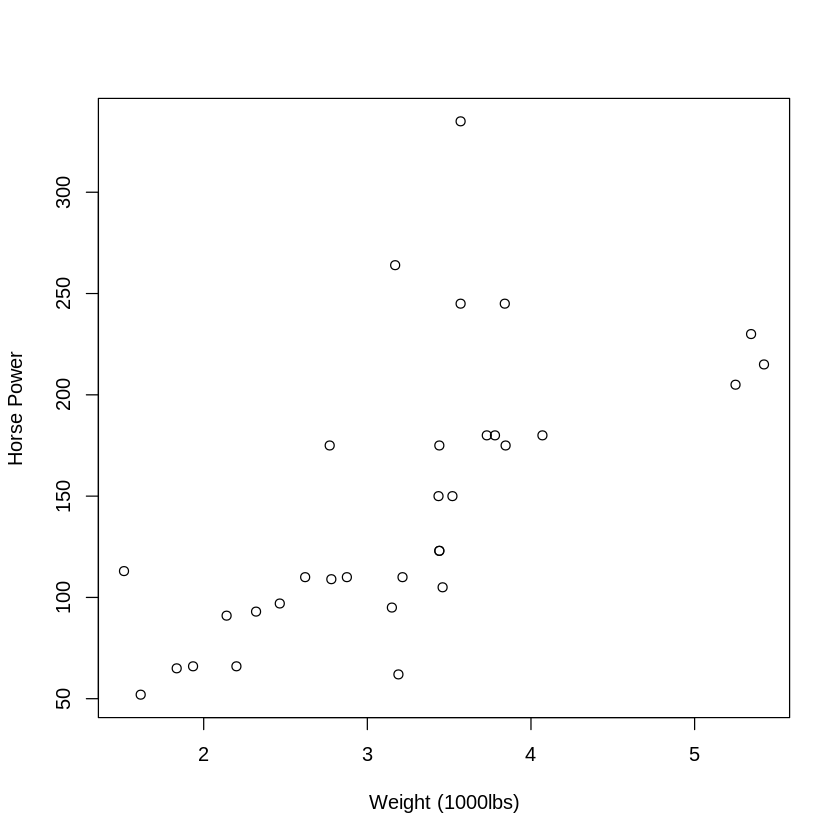

In [3]:
plot(mtcars$wt, mtcars$hp,
     xlab = "Weight (1000lbs)",
     ylab = "Horse Power")

It appears that engines generally have more horse power / more powerful engines on average. The relationship appears to be a weak positive linear association.

<br>

<font color=red>Task 2.2</font>

* Fit a simple linear regression between weight (x-variable) and horsepower (y-variable) and store as the variable `fit_wt`

* Use the `coef()` function to show the coefficients (i.e. interept and slope estimates) of the regression

In [4]:
# fit a linear regression with lm()

fit_wt <- lm(hp ~ wt, data = mtcars)

# show coefficients
coef(fit_wt)

(Intercept)          wt 
  -1.820922   46.160050

In [5]:
# summary of linear regression
summary(fit_wt)


Call:
lm(formula = hp ~ wt, data = mtcars)

Residuals:
    Min      1Q  Median      3Q     Max 
-83.430 -33.596 -13.587   7.913 172.030 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   -1.821     32.325  -0.056    0.955    
wt            46.160      9.625   4.796 4.15e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 52.44 on 30 degrees of freedom
Multiple R-squared:  0.4339,	Adjusted R-squared:  0.4151 
F-statistic:    23 on 1 and 30 DF,  p-value: 4.146e-05


<br>

<font color=red>Task 2.3</font>

* What is the interpretation of the slope of the regression in the context of weight being 1000s of pounds?

* What is the interpretation of the intercept of the regression? Does this interpretation make sense? Why/why not?

The slope of 46.16 indicates that vehicles with an additonal 1000 lbs in weight have a 46.16 higher horse power on average. // For every 1000 lbs increase in weight, we exoect horse power to increase by 46.16 on average.

The intercept indicates that vehicles weighing 0 lbs have -1.82 horse power. This does not make sense since vehicles must have positive weight and horse power cannot be negative.

<br>

<font color=red>Task 2.4</font>

* Replot weight and horsepower and use `abline()` to overlay your regression fit on the plot

* In your opinion, is this a "good" fit? Why/why not?

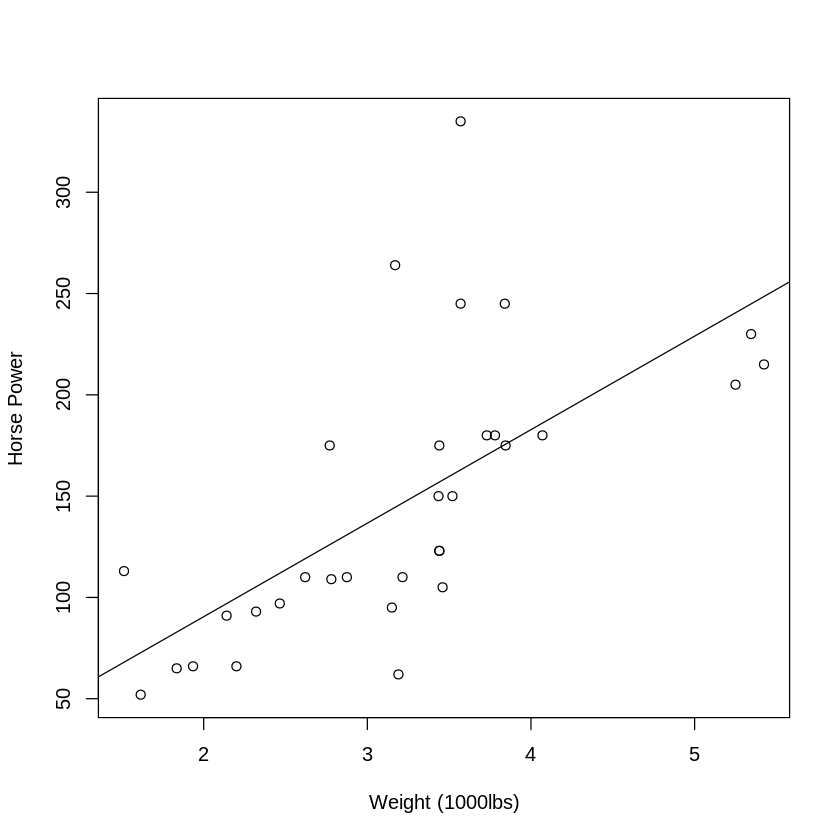

In [6]:
plot(mtcars$wt, mtcars$hp,
     xlab = "Weight (1000lbs)",
     ylab = "Horse Power")
abline(fit_wt)

The linear regression does an okay job, however, there is a good amount of scatter about the regression line indicating that the strength of the linear relationship is weak. There are some points that may be outliers that generate linear residuals with this regression model.

<br>

<br>

<br>

---

####<font color=red>Task 3</font>

<font color=red>Task 3.1</font>

* Create a 95% confidence interval for the slope of the regression from Task 2.

In [7]:
# number of bootstrap samples
B <- 2000

# sample size
n <- nrow(mtcars)

# vector to store values
boot_slopes <- vector(length = B)

# vector to calculate many bootstrap samples
for( i in 1:B) {

  # sample indexes
  boot_index <- sample(1:nrow(mtcars), size = n, replace = TRUE)

  # extract bootstrap sample
  boot_samp <- mtcars[boot_index, ]

  # compute regression coefficients of single bootstrap sample
  boot_fit <- lm(hp~wt, data = boot_samp)

  # store the bootstrap regression coefficient
  boot_slopes[i] <- coef(boot_fit)[2]
}

# calculate 95% confidence interval
print(quantile(boot_slopes, probs = c(0.025, 0.975)))

    2.5%    97.5% 
36.30393 63.03539 


<br>

<font color=red>Task 3.2</font>

* What is the interpretation of the 95% confidence interval from Task 3.1?

We are 95% confident that the true population slope for the simple linear regression between horse power and weight is within this interval [36.31, 63.04].

<br>

<font color=red>Task 3.3</font>

* Based on this confidence interval, are `hp` and `wt` significantly correlated? Explain your answer using the confidence interval.

* Based on this confidence interval, is the slope significantly different than 50? Explain your answer.

Based on the 95% confidence interval, the slope is significantly different from 0 since 0 is not contained within the interval. Therefore, horsepower and weight are significantly correlated with each other.

The slope is not significantly different from 50 since 50 is contained within the confidence interval.